In [1]:
## IMPORTS
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/TFM_NoeliaGarciaGarcia/Pipeline'
else:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"Entorno: {'Colab' if IN_COLAB else 'Local'}")
print(f"BASE_PATH: {BASE_PATH}")

Entorno: Local
BASE_PATH: g:\Mi unidad\TFM_NoeliaGarciaGarcia\TFM_OxygenFlux\Pipeline


# CARGA DE DATOS

In [2]:
df_b1 = pd.read_csv(os.path.join(BASE_PATH, "DATA", "MASTER", "NM03E302DOb1.dat"), sep=r"\s+")

df_b2 = pd.read_csv(os.path.join(BASE_PATH, "DATA", "MASTER", "NM03E302DOb2.dat"), sep=r"\s+")

# Unir en vertical
df_flux2 = pd.concat([df_b1, df_b2], axis=0, ignore_index=True)

# Nos quedamos solo con lo necesario
df_flux2 = df_flux2[["Time1", "Flux2", "O2mean", "vzMeanNoR"]].copy()

# Renombrado
df_flux2 = df_flux2.rename(columns={
    "Time1": "hour",
    "Flux2": "flux_O2"
})

# Orden temporal
df_flux2 = df_flux2.sort_values("hour").reset_index(drop=True)

In [3]:
df_final = pd.read_csv(os.path.join(BASE_PATH, "DATA", "PROCESSED", "df_flux.csv"), sep=r",")

df_final= df_final[["hour", "flux_O2", "flux_smooth", "optimal_shift_samples", "mean_vz", "mean_temp", "mean_O2", "mean_pres", "accumulated_flux_O2"]].copy()

In [4]:
df_flux_clean = pd.read_csv(os.path.join(BASE_PATH, "DATA", "CLEAN", "df_flux_clean.csv"), sep=r",")

df_flux_clean = df_flux_clean[["window_id", "hour", "flux_O2", "flux_smooth", "optimal_shift_samples", "mean_vz", "mean_temp", "mean_O2", "mean_pres", "accumulated_flux_O2"]].copy()

In [5]:
df_flux_master = pd.read_csv(os.path.join(BASE_PATH, "DATA", "CLEAN", "df_flux_master.csv"), sep=r",")

df_flux_master = df_flux_master[["window_id","hour", "flux_O2", "flux_smooth", "optimal_shift_samples", "mean_vz", "mean_temp", "mean_O2", "mean_pres", "accumulated_flux_O2"]].copy()

In [6]:
qc = pd.read_csv(os.path.join(BASE_PATH, "DATA", "CLEAN", "qc.csv"), sep=r",")

# COMPARACIÓN DE DATASETS

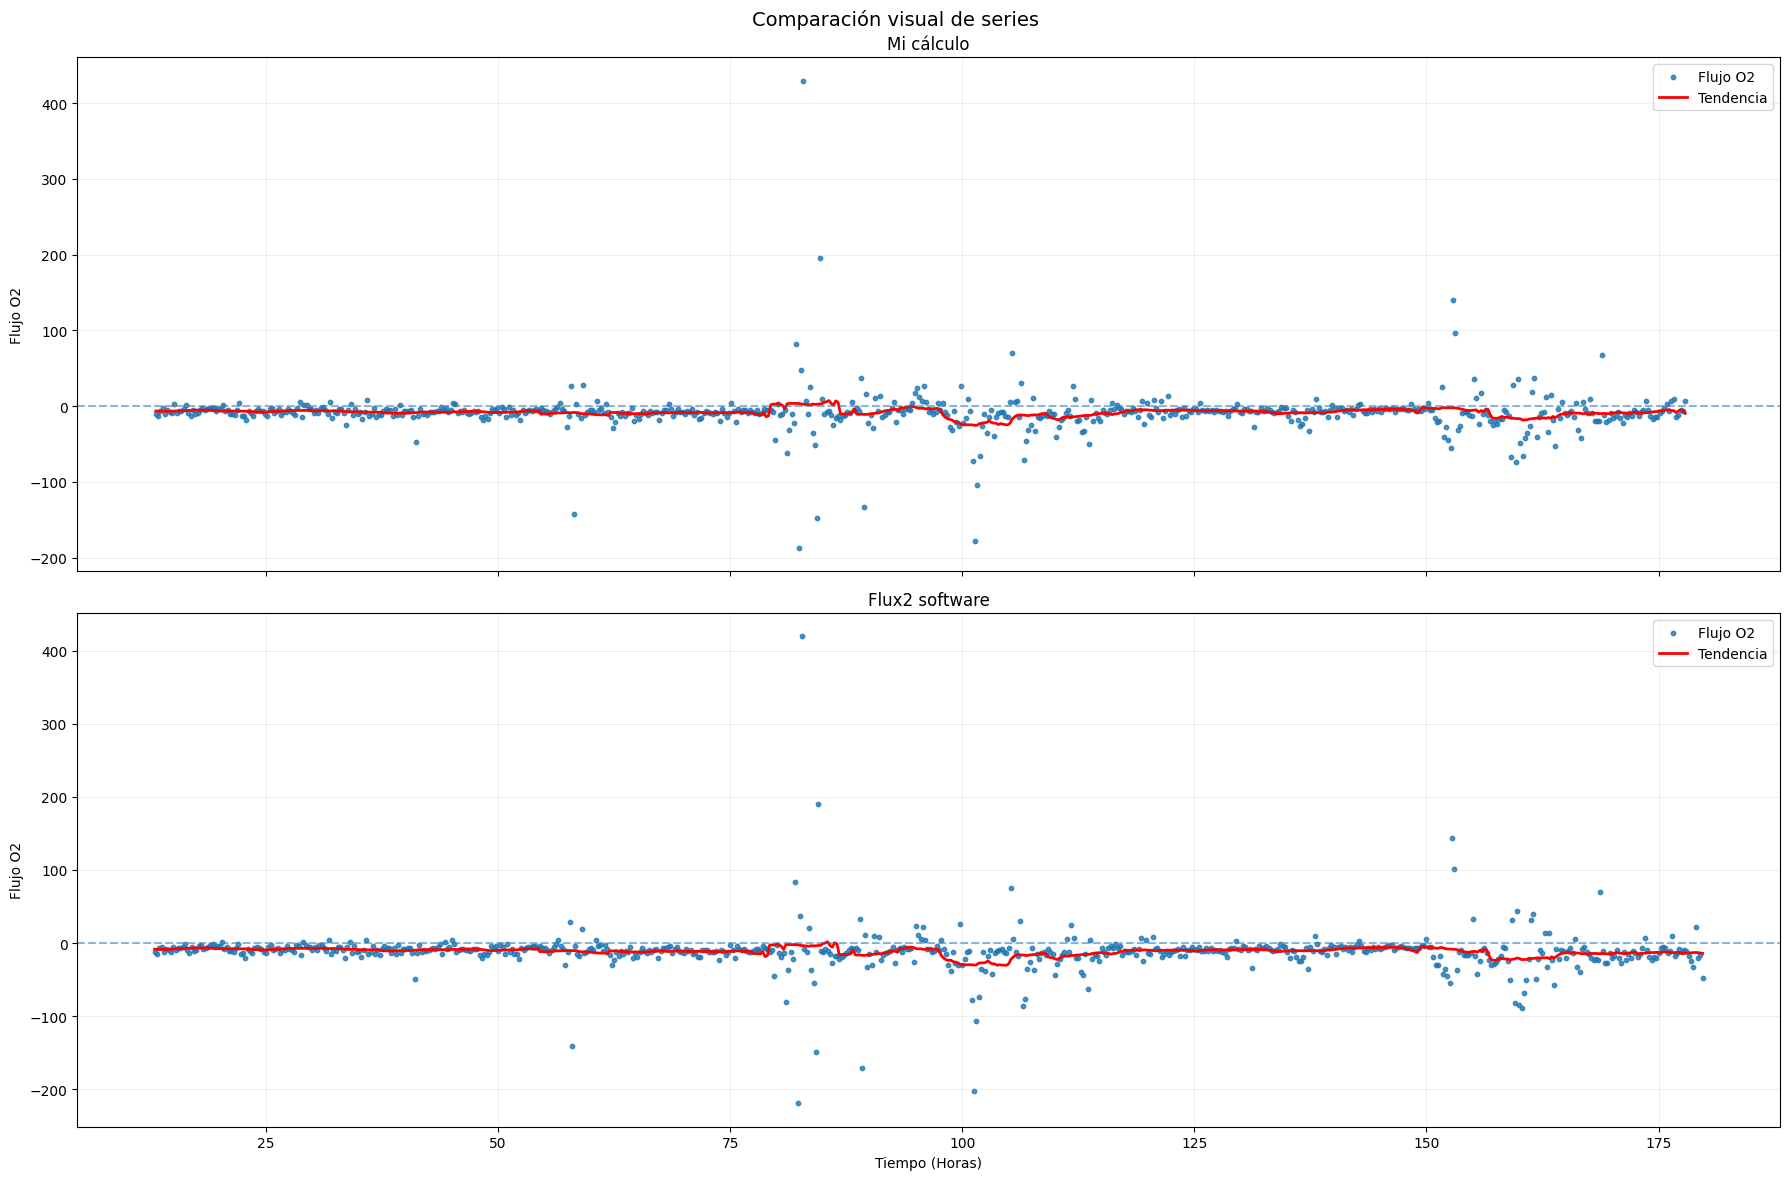

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True) # Changed to 2 rows, 1 column, and sharex for time series

# Calculate smooth for df_flux2
smooth_window = 30 # Use the same window as procesar_dataset_completo
df_flux2['flux_smooth'] = df_flux2['flux_O2'].rolling(
    window=smooth_window,
    center=True,
    min_periods=1
).mean()

# --- Mi cálculo ---
axes[0].scatter(
    df_final["hour"],
    df_final["flux_O2"],
    alpha=0.8,
    s=10, # Marker size
    label="Flujo O2"
)
axes[0].plot(
    df_final['hour'],
    df_final['flux_smooth'],
    linewidth=2,
    color='red', # Make trend line distinct
    label='Tendencia'
)
axes[0].axhline(0, linestyle="--", alpha=0.5)
axes[0].set_ylabel("Flujo O2") # Changed to set_ylabel as x-axis is shared
axes[0].set_title("Mi cálculo")
axes[0].grid(True, alpha=0.2)
axes[0].legend()

# --- Flux2 software ---
axes[1].scatter(
    df_flux2["hour"],
    df_flux2["flux_O2"],
    alpha=0.8,
    s=10, # Marker size
    label="Flujo O2"
)
axes[1].plot(
    df_flux2['hour'],
    df_flux2['flux_smooth'],
    linewidth=2,
    color='red', # Make trend line distinct
    label='Tendencia'
)
axes[1].axhline(0, linestyle="--", alpha=0.5)
axes[1].set_xlabel("Tiempo (Horas)")
axes[1].set_ylabel("Flujo O2") # Changed to set_ylabel as x-axis is shared
axes[1].set_title("Flux2 software") # Added title for the second plot
axes[1].grid(True, alpha=0.2)
axes[1].legend()

fig.suptitle("Comparación visual de series", fontsize=14)
plt.tight_layout()
plt.show()

# GRÁFICA DE ACUMULADOS

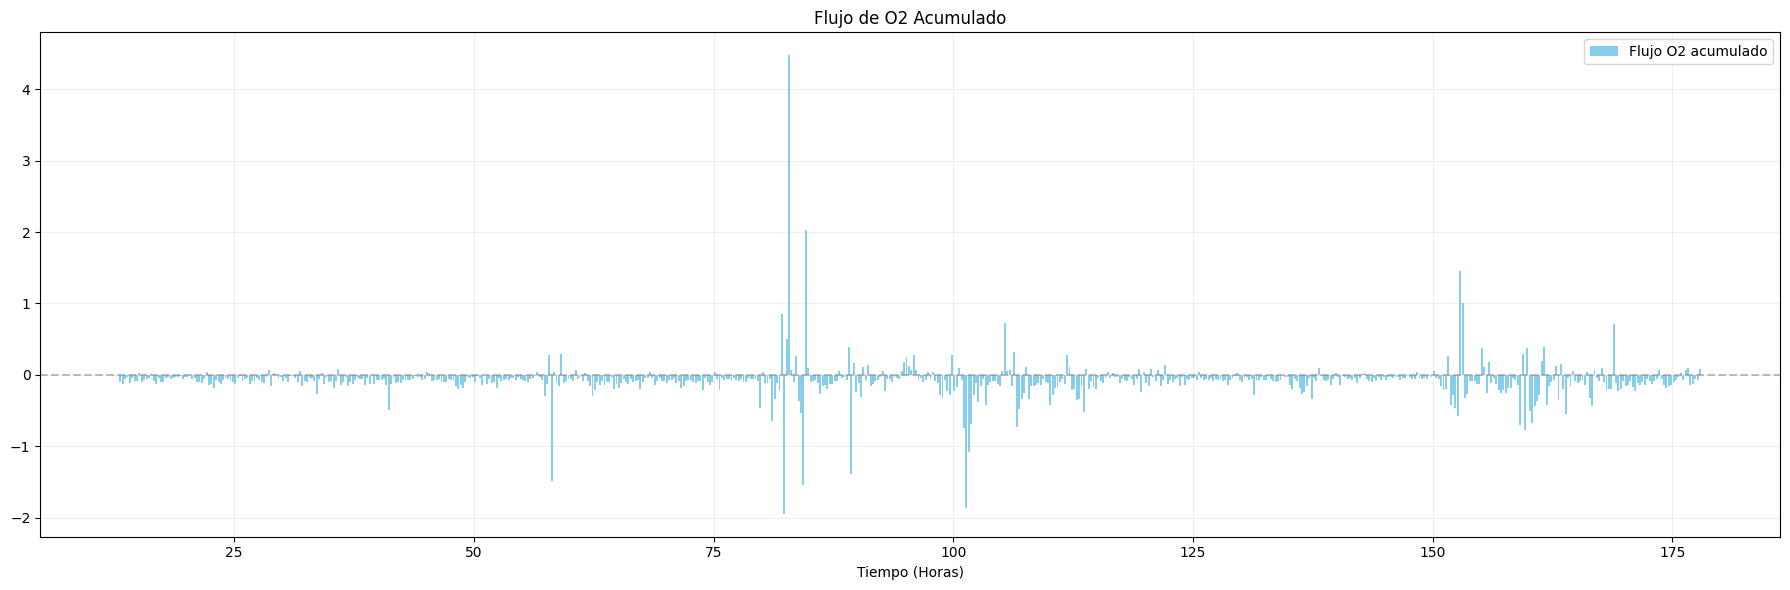

In [8]:
fig, ax = plt.subplots(figsize=(18, 6))

ax.bar(
    df_final['hour'],
    df_final['accumulated_flux_O2'],
    width=0.2,
    color='skyblue',
    label='Flujo O2 acumulado'
)

ax.axhline(0, linestyle="--", alpha=0.5, color='gray')
ax.set_xlabel("Tiempo (Horas)")
ax.set_title("Flujo de O2 Acumulado")
ax.grid(True, alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()

# INTERVALOS

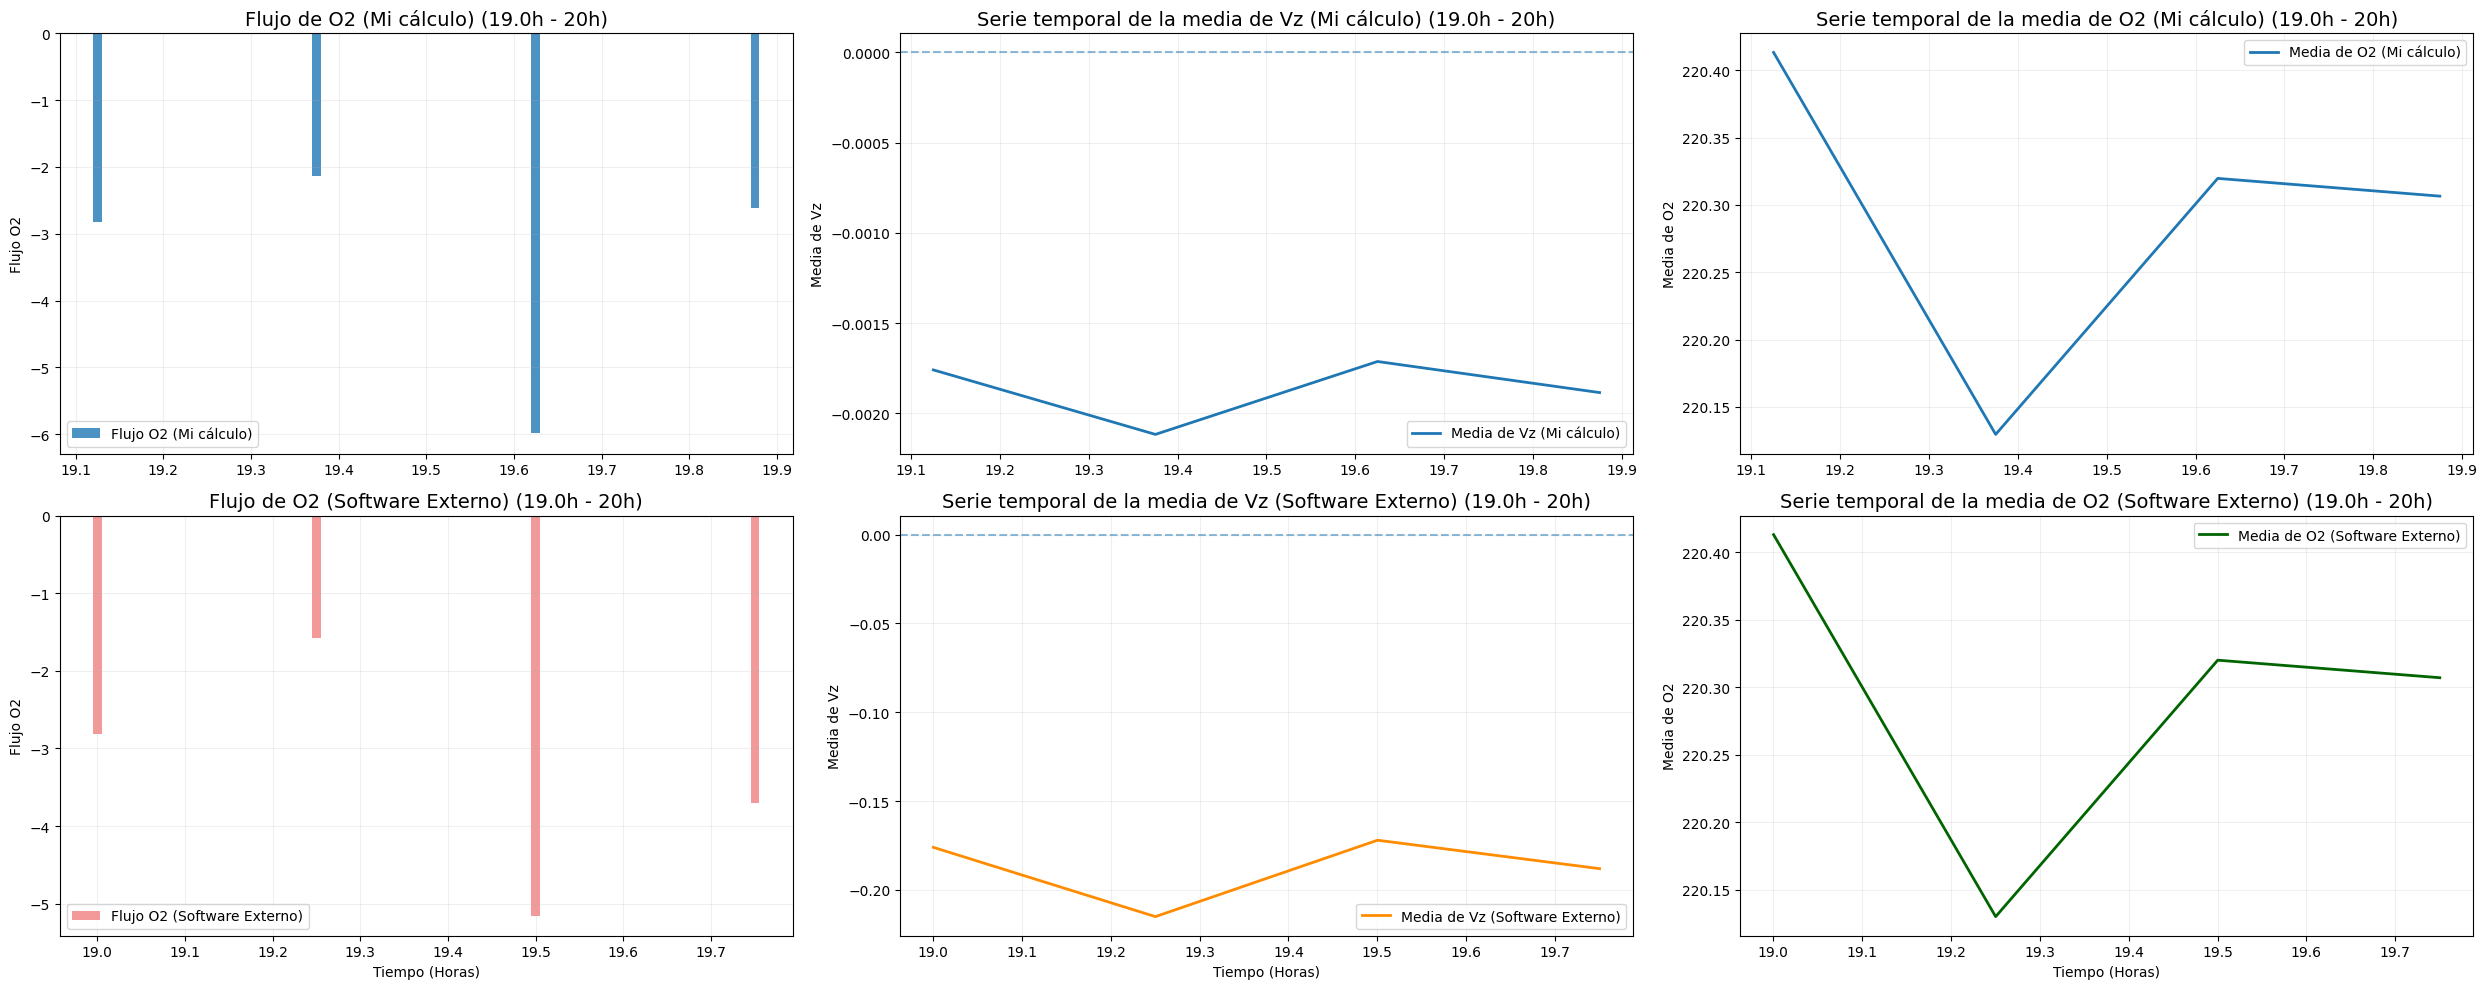

In [9]:
start_time = 19.0
end_time = 20

# Filtra el DataFrame para el intervalo seleccionado
df_interval = df_final[(df_final['hour'] >= start_time) & (df_final['hour'] <= end_time)].copy()
df_flux2_interval = df_flux2[(df_flux2['hour'] >= start_time) & (df_flux2['hour'] <= end_time)].copy()

fig, axes = plt.subplots(2, 3, figsize=(25, 10)) # 2 filas, 3 columnas, ajustamos figsize

# --- Primera Fila (df_final) ---

# Plot para Flujo de O2 (df_final)
axes[0, 0].bar(
    df_interval['hour'],
    df_interval['flux_O2'],
    width=0.01,
    alpha=0.8,
    label='Flujo O2 (Mi cálculo)'
)
axes[0, 0].axhline(0, linestyle='--', alpha=0.5)
axes[0, 0].set_title(f'Flujo de O2 (Mi cálculo) ({start_time}h - {end_time}h)', fontsize=14)
axes[0, 0].set_ylabel('Flujo O2')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.2)

# Plot para Media de Vz (df_final_filtered)
axes[0, 1].plot(
    df_interval['hour'],
    df_interval['mean_vz'],
    linewidth=2,
    label='Media de Vz (Mi cálculo)'
)
axes[0, 1].axhline(0, linestyle='--', alpha=0.5)
axes[0, 1].set_title(f'Serie temporal de la media de Vz (Mi cálculo) ({start_time}h - {end_time}h)', fontsize=14)
axes[0, 1].set_ylabel('Media de Vz')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.2)

# Plot para Media de O2 (df_final_filtered)
axes[0, 2].plot(
    df_interval['hour'],
    df_interval['mean_O2'],
    linewidth=2,
    label='Media de O2 (Mi cálculo)'
)
axes[0, 2].set_title(f'Serie temporal de la media de O2 (Mi cálculo) ({start_time}h - {end_time}h)', fontsize=14)
axes[0, 2].set_ylabel('Media de O2')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.2)


# --- Segunda Fila (df_flux2) ---

# Plot para Flujo de O2 (df_flux2)
axes[1, 0].bar(
    df_flux2_interval['hour'],
    df_flux2_interval['flux_O2'],
    width=0.01,
    alpha=0.8,
    color='lightcoral', # Different color for distinction
    label='Flujo O2 (Software Externo)'
)
axes[1, 0].axhline(0, linestyle='--', alpha=0.5)
axes[1, 0].set_title(f'Flujo de O2 (Software Externo) ({start_time}h - {end_time}h)', fontsize=14)
axes[1, 0].set_xlabel('Tiempo (Horas)') # Add x-label to the bottom row
axes[1, 0].set_ylabel('Flujo O2')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.2)

# Plot para Media de Vz (df_flux2)
axes[1, 1].plot(
    df_flux2_interval['hour'],
    df_flux2_interval['vzMeanNoR'],
    linewidth=2,
    color='darkorange', # Different color for distinction
    label='Media de Vz (Software Externo)'
)
axes[1, 1].axhline(0, linestyle='--', alpha=0.5)
axes[1, 1].set_title(f'Serie temporal de la media de Vz (Software Externo) ({start_time}h - {end_time}h)', fontsize=14)
axes[1, 1].set_xlabel('Tiempo (Horas)')
axes[1, 1].set_ylabel('Media de Vz')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.2)

# Plot para Media de O2 (df_flux2)
axes[1, 2].plot(
    df_flux2_interval['hour'],
    df_flux2_interval['O2mean'],
    linewidth=2,
    color='darkgreen', # Different color for distinction
    label='Media de O2 (Software Externo)'
)
axes[1, 2].set_title(f'Serie temporal de la media de O2 (Software Externo) ({start_time}h - {end_time}h)', fontsize=14)
axes[1, 2].set_xlabel('Tiempo (Horas)')
axes[1, 2].set_ylabel('Media de O2')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# SEDIMENTO

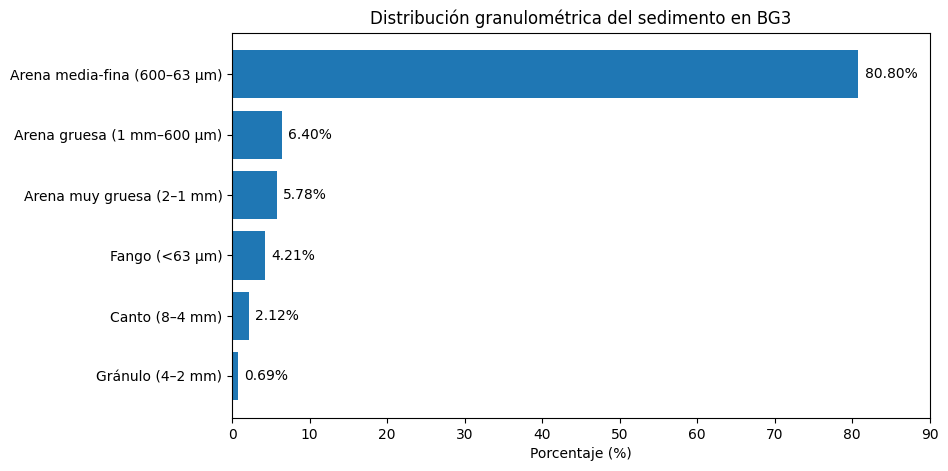

In [13]:
categorias = [
    "Arena media-fina (600–63 µm)",
    "Arena gruesa (1 mm–600 µm)",
    "Arena muy gruesa (2–1 mm)",
    "Fango (<63 µm)",
    "Canto (8–4 mm)",
    "Gránulo (4–2 mm)"
]


valores_originales = np.array([82.13, 6.51, 5.88, 4.28, 2.15, 0.70])

# Normalización
porcentajes = valores_originales / valores_originales.sum() * 100

# Ordenar de mayor a menor
datos = sorted(zip(categorias, porcentajes), key=lambda x: x[1])
categorias_ord, porcentajes_ord = zip(*datos)

plt.figure(figsize=(9, 5))

bars = plt.barh(categorias_ord, porcentajes_ord)

for bar, valor in zip(bars, porcentajes_ord):
    plt.text(
        valor + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{valor:.2f}%",
        va="center",
        fontsize=10
    )

plt.xlabel("Porcentaje (%)")
plt.title("Distribución granulométrica del sedimento en BG3")
plt.xlim(0, 90)

plt.show()

# COMPARACIONES DE INTERPOLACION

Ventanas comparadas: 660
Ventanas con interpolación: 322 (48.8%)
|clean-master| medio en ventanas interpoladas: 0.307
|clean-master| medio en ventanas no interpoladas: 0.000


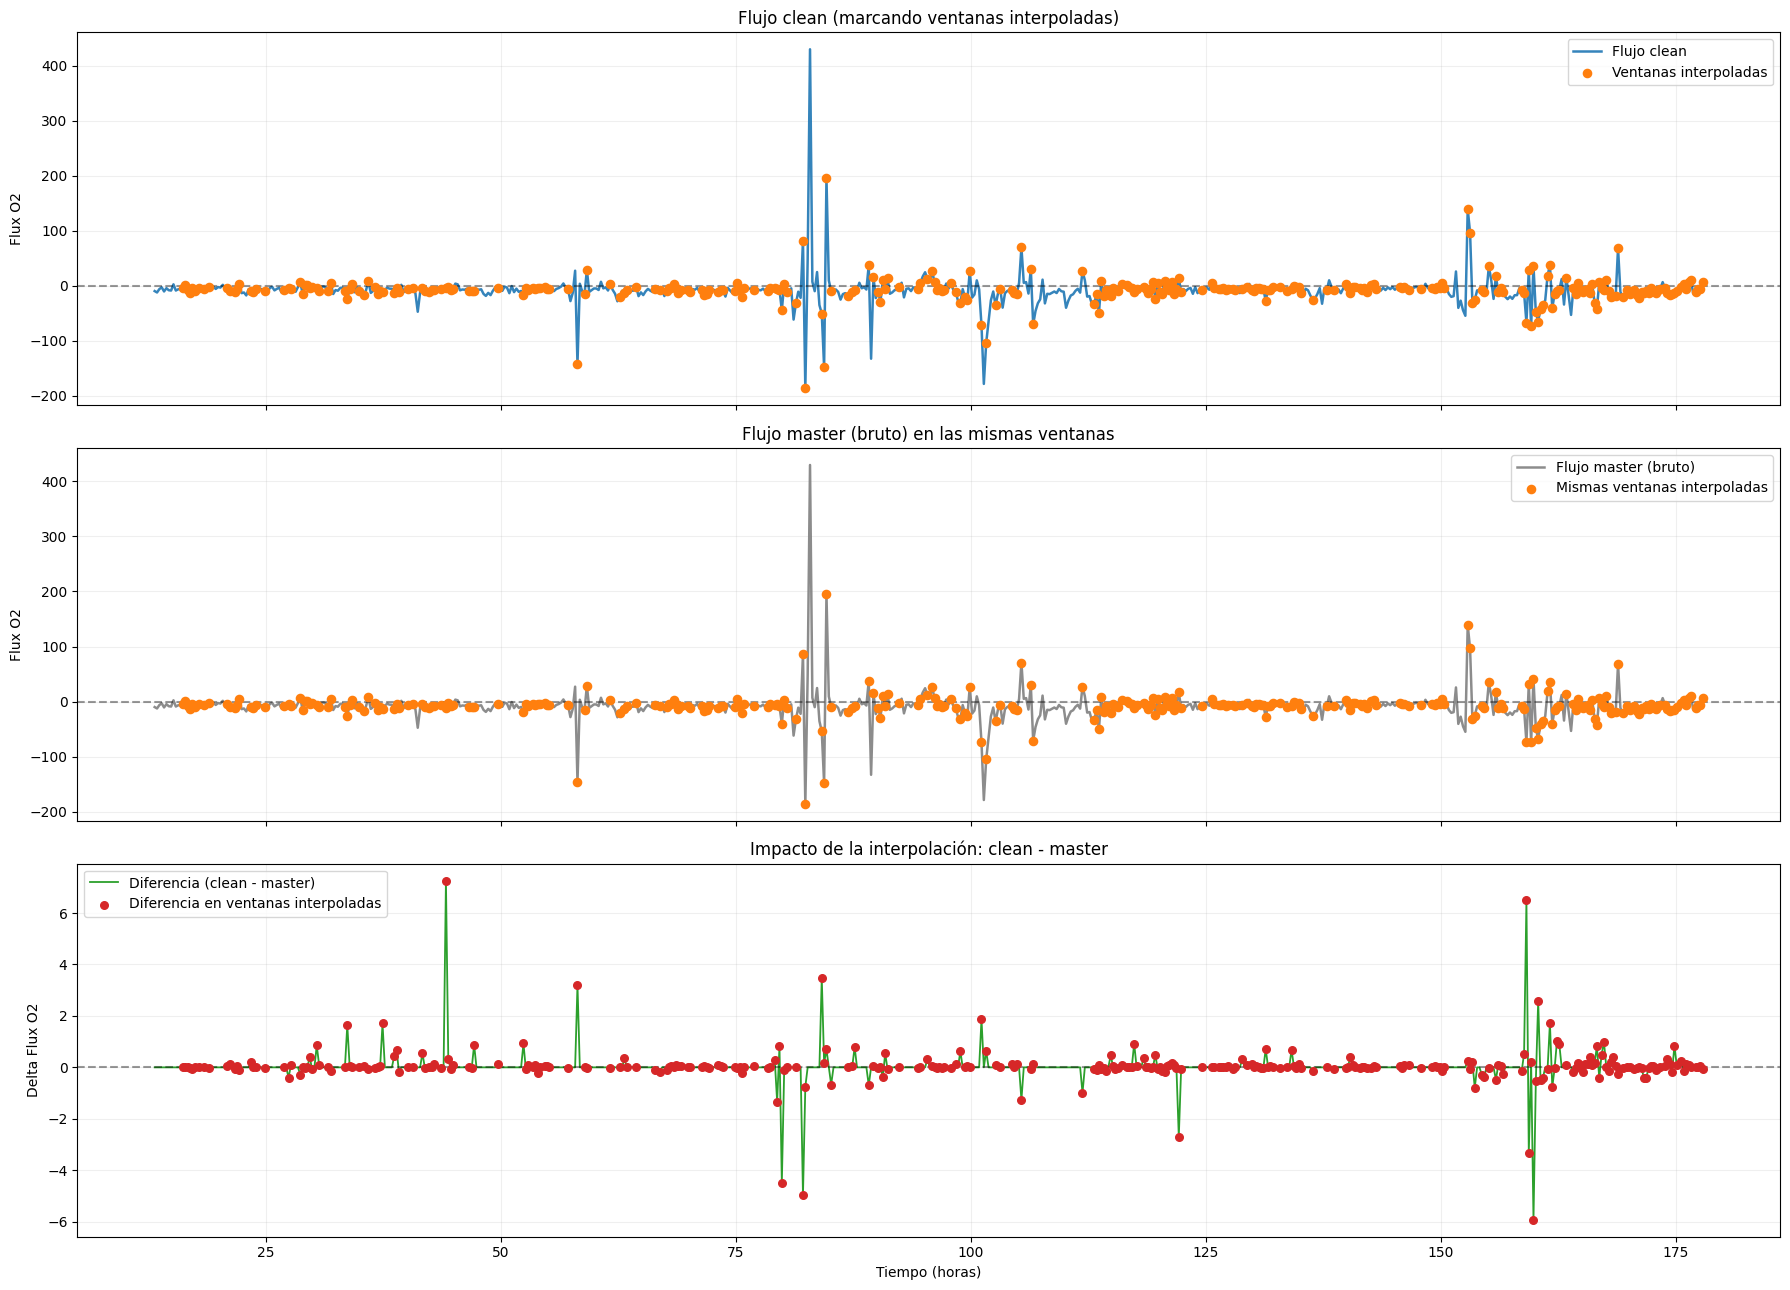

In [11]:
# Comparación: flujo con limpieza/interpolación vs flujo bruto (sin limpieza)
# y marcado de ventanas donde realmente se interpoló.

# 1) Construir bandera de interpolación por ventana a partir de qc
qc_cmp = qc.copy()
for col in ["n_interpolated_O2", "n_interpolated_vz"]:
    if col not in qc_cmp.columns:
        qc_cmp[col] = 0

qc_cmp["interpolated_window"] = (
    (qc_cmp["n_interpolated_O2"] > 0) |
    (qc_cmp["n_interpolated_vz"] > 0)
)

qc_cmp = qc_cmp[["window_id", "interpolated_window", "n_interpolated_O2", "n_interpolated_vz"]].copy()

# 2) Preparar tablas para comparación
clean_cmp = df_flux_clean[["window_id", "hour", "flux_O2"]].rename(
    columns={"flux_O2": "flux_clean"}
)

master_cmp = df_flux_master[["window_id", "hour", "flux_O2"]].rename(
    columns={"flux_O2": "flux_master"}
)

cmp = clean_cmp.merge(
    master_cmp[["window_id", "flux_master"]],
    on="window_id",
    how="inner"
).merge(
    qc_cmp,
    on="window_id",
    how="left"
)

cmp["interpolated_window"] = cmp["interpolated_window"].fillna(False)
cmp["flux_diff"] = cmp["flux_clean"] - cmp["flux_master"]
cmp = cmp.sort_values("hour").reset_index(drop=True)

# 3) Métricas rápidas
n_total = len(cmp)
n_interp = int(cmp["interpolated_window"].sum())

mean_abs_diff_interp = cmp.loc[cmp["interpolated_window"], "flux_diff"].abs().mean()
mean_abs_diff_no_interp = cmp.loc[~cmp["interpolated_window"], "flux_diff"].abs().mean()

print(f"Ventanas comparadas: {n_total}")
print(f"Ventanas con interpolación: {n_interp} ({100*n_interp/n_total:.1f}%)")
print(f"|clean-master| medio en ventanas interpoladas: {mean_abs_diff_interp:.3f}")
print(f"|clean-master| medio en ventanas no interpoladas: {mean_abs_diff_no_interp:.3f}")

# 4) Gráfica comparativa en 3 paneles
fig, axes = plt.subplots(3, 1, figsize=(18, 13), sharex=True)

interp_pts = cmp[cmp["interpolated_window"]]

# Panel 1: flujo clean con ventanas interpoladas destacadas
axes[0].plot(
    cmp["hour"],
    cmp["flux_clean"],
    color="tab:blue",
    linewidth=1.8,
    alpha=0.9,
    label="Flujo clean"
)
axes[0].scatter(
    interp_pts["hour"],
    interp_pts["flux_clean"],
    color="tab:orange",
    s=35,
    zorder=5,
    label="Ventanas interpoladas"
)
axes[0].axhline(0, linestyle="--", color="black", alpha=0.4)
axes[0].set_ylabel("Flux O2")
axes[0].set_title("Flujo clean (marcando ventanas interpoladas)")
axes[0].grid(True, alpha=0.2)
axes[0].legend()

# Panel 2: flujo master con ventanas interpoladas (de clean) destacadas
axes[1].plot(
    cmp["hour"],
    cmp["flux_master"],
    color="gray",
    linewidth=1.8,
    alpha=0.9,
    label="Flujo master (bruto)"
)
axes[1].scatter(
    interp_pts["hour"],
    interp_pts["flux_master"],
    color="tab:orange",
    s=35,
    zorder=5,
    label="Mismas ventanas interpoladas"
)
axes[1].axhline(0, linestyle="--", color="black", alpha=0.4)
axes[1].set_ylabel("Flux O2")
axes[1].set_title("Flujo master (bruto) en las mismas ventanas")
axes[1].grid(True, alpha=0.2)
axes[1].legend()

# Panel 3: diferencia clean - master
axes[2].plot(
    cmp["hour"],
    cmp["flux_diff"],
    color="tab:green",
    linewidth=1.3,
    label="Diferencia (clean - master)"
)
axes[2].scatter(
    interp_pts["hour"],
    interp_pts["flux_diff"],
    color="tab:red",
    s=30,
    zorder=5,
    label="Diferencia en ventanas interpoladas"
)
axes[2].axhline(0, linestyle="--", color="black", alpha=0.4)
axes[2].set_xlabel("Tiempo (horas)")
axes[2].set_ylabel("Delta Flux O2")
axes[2].set_title("Impacto de la interpolación: clean - master")
axes[2].grid(True, alpha=0.2)
axes[2].legend()

plt.tight_layout()
plt.show()

In [12]:
# Tabla de apoyo: top ventanas donde más cambia el flujo tras limpieza/interpolación
cmp.reindex(cmp["flux_diff"].abs().sort_values(ascending=False).index).head(10)

,window_id,hour,flux_clean,flux_master,interpolated_window,n_interpolated_O2,n_interpolated_vz,flux_diff
124,124,44.125009,-4.594174,-11.852460,True,33,26,7.258287
584,584,159.125009,-67.224906,-73.719459,True,0,33,6.494554
587,587,159.875009,35.741204,41.667156,True,0,4,-5.925952
276,276,82.125009,81.878617,86.857837,True,57,0,-4.979220
267,267,79.875009,-44.646674,-40.143280,True,0,12,-4.503394
284,284,84.125009,-50.681940,-54.164296,True,61,2,3.482356
585,585,159.375009,28.269171,31.608957,True,194,12,-3.339786
180,180,58.125009,-142.503129,-145.707458,True,217,0,3.204329
436,436,122.125009,13.923029,16.624805,True,85,0,-2.701775
589,589,160.375009,-65.356196,-67.936374,True,0,4,2.580177
